# The Machine Learning Workflow
## Machine Learning — BS Computer Science 3(3-0)



| | |
|---|---|
| **Notebook** | `NB01_ML_Workflow.ipynb` |
| **Lecture** | Lectures 1–2 (Week 1) |
| **CLO** | CLO-1 |
| **Dataset** | Iris (bundled with scikit-learn) |

**Objective.** Establish the vocabulary, the notation and the split discipline that every later notebook depends on.

**By the end of this notebook you will be able to:**

1. Load a dataset and read its shape aloud as 'n samples, m features'.
2. Distinguish supervised, unsupervised and reinforcement learning for a described problem.
3. Produce a stratified train/test split with a fixed seed and verify the class proportions.
4. State the five stages of the ML workflow.

---

## 0. Setup and reproducibility

In [21]:
# ---------------------------------------------------------------------
# Reproducibility header — required in EVERY notebook you submit
# ---------------------------------------------------------------------
import sys, numpy as np, pandas as pd, sklearn, matplotlib
import matplotlib.pyplot as plt

print('python      ', sys.version.split()[0])
print('numpy       ', np.__version__)
print('pandas      ', pd.__version__)
print('scikit-learn', sklearn.__version__)
print('matplotlib  ', matplotlib.__version__)

RANDOM_STATE = 1
rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

python       3.13.15
numpy        2.1.3
pandas       2.2.3
scikit-learn 1.6.1
matplotlib   3.10.0


## 1. Loading a dataset

The Iris dataset contains 150 flowers of three species, each described by four measurements in centimetres. It is the textbook's running example (Raschka Ch. 1).

The universal convention is **rows are samples, columns are features**, so `X.shape` must always read `(n_samples, n_features)`.

In [22]:
from sklearn.datasets import load_iris

data = load_iris()
X, y = data.data, data.target

print('X shape :', X.shape)          # (150, 4) -> 150 samples, 4 features
print('y shape :', y.shape)
print('features:', data.feature_names)
print('classes :', data.target_names)
print()
print('x_1^(150) — sepal length of flower 150 =', X[149, 0])

X shape : (150, 4)
y shape : (150,)
features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
classes : ['setosa' 'versicolor' 'virginica']

x_1^(150) — sepal length of flower 150 = 5.9


> **Read the shape out loud in words**, not as numbers: *'150 samples, 4 features.'* If it ever prints `(4, 150)` your matrix is transposed and scikit-learn will train on nonsense.

## 2. A first look at the data

These six lines are the standard first look at any dataset in this course.

In [23]:
df = pd.DataFrame(X, columns=data.feature_names)
df['species'] = pd.Categorical.from_codes(y, data.target_names)

print(df.shape)
display(df.head())
df.info()
display(df.describe().round(2))
print()
print('class balance:')
print(df['species'].value_counts(normalize=True))
print()
print('missing values per column:')
print(df.isnull().sum())

(150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50



class balance:
species
setosa        0.333333
versicolor    0.333333
virginica     0.333333
Name: proportion, dtype: float64

missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


**Interpretation (write two sentences).**

*What is one row of this dataset? Are the four features on comparable scales, and does that matter for the models you will build in Week 3?*

>Each row represents one flower, described by four features: sepal length, sepal width, petal length, and petal width, all measured in centimetres. Although the four features use the same unit, they are not on exactly the same numerical scale, so scaling can matter for models that are sensitive to feature magnitude.

## 3. Seeing whether the classes are separable

Before fitting anything, plot the data. A class-coloured scatter answers the question *are these classes separable at all?*

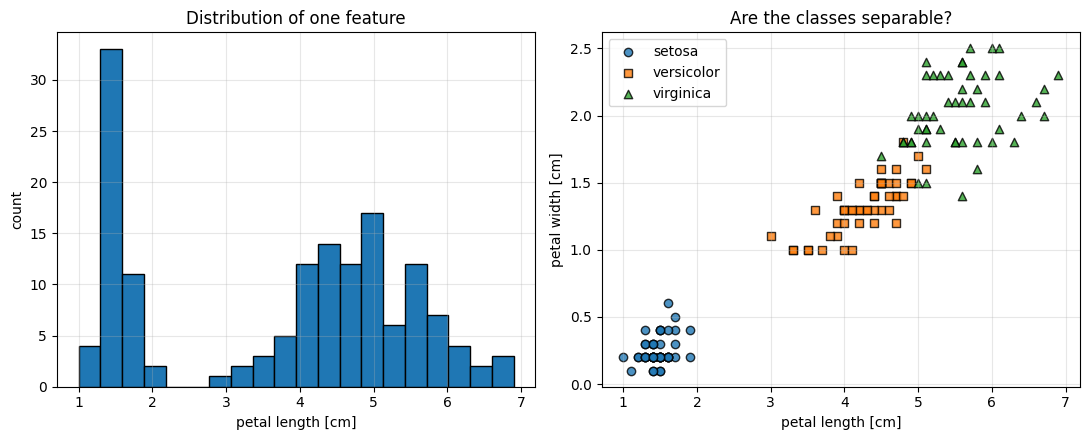

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

ax[0].hist(X[:, 2], bins=20, edgecolor='black')
ax[0].set_xlabel('petal length [cm]')
ax[0].set_ylabel('count')
ax[0].set_title('Distribution of one feature')

for label, marker in zip(np.unique(y), ('o', 's', '^')):
    ax[1].scatter(X[y == label, 2], X[y == label, 3],
                  marker=marker, alpha=0.8, edgecolor='k',
                  label=data.target_names[label])
ax[1].set_xlabel('petal length [cm]')
ax[1].set_ylabel('petal width [cm]')
ax[1].set_title('Are the classes separable?')
ax[1].legend()

plt.tight_layout()
plt.show()

## 4. The split — the experiment that measures generalisation

Generalisation is the only result that counts, so you must deliberately hide data from yourself. `random_state` makes the split reproducible; `stratify` preserves the class proportions on both sides.

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

print('train', X_train.shape, ' test', X_test.shape)
print()
print('train class proportions:', np.round(np.bincount(y_train) / len(y_train), 3))
print('test  class proportions:', np.round(np.bincount(y_test) / len(y_test), 3))

train (105, 4)  test (45, 4)

train class proportions: [0.333 0.333 0.333]
test  class proportions: [0.333 0.333 0.333]


### Exercise 4.1 — what stratification prevents

Build a deliberately imbalanced target (say 95% class 0), split it **without** `stratify`, and print the class counts in the test set. Repeat with `stratify`.

In [26]:
# TODO: create an imbalanced y_imb where ~95% of labels are 0
# y_imb = ...
y_imb = np.array([0] * 95 + [1] * 5)
X_dummy = np.arange(100).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X_dummy, y_imb, test_size=0.3, random_state=RANDOM_STATE
)

print("Without stratify:", np.bincount(y_test))
X_train, X_test, y_train, y_test = train_test_split(
    X_dummy, y_imb, test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y_imb
)

print("With stratify:", np.bincount(y_test))
# Without stratification, the random split can give the test set a distorted class distribution.

Without stratify: [29  1]
With stratify: [28  2]


## 5. Classify the problem type

Complete the table below. For each problem give the learning type, the specific task, the target variable if one exists, and one risk of getting the prediction wrong.

| # | Problem | Learning type | Task | Target | Risk if wrong |
|---|---|---|---|---|---|
| 1 | Predict which students will fail from attendance and quiz history | Supervised | Classification | Pass/fail status | A student needing support may not be identified |
| 2 | Group 50,000 supermarket customers for a campaign | Unsupervised | Clustering | None | Customers may be placed in inappropriate groups, leading to an ineffective campaign |
| 3 | Estimate apartment rent from area, location and rooms | Supervised | Regression | Apartment rent | Incorrect rent estimates may lead to poor pricing or financial decisions |
| 4 | Teach a drone to reach a rooftop on minimum battery | Reinforcement | Sequential decision-making / control | None | The drone may waste battery or fail to reach the rooftop |
| 5 | Detect intrusions given 900 labelled attacks and 4M unlabelled sessions | Supervised | Classification | Intrusion/attack status | A real intrusion could be missed |
| 6 | Compress 784-pixel digit images to two numbers for plotting | Unsupervised | Dimensionality reduction | None | Important information may be lost, making the visualization misleading |

## 6. The workflow, stated

Every project in this course — including your semester project — follows these five stages (Raschka Ch. 1, 'A roadmap for building machine learning systems').

1. **Preprocessing** — missing values, encoding, scaling, splitting. 60–80% of real effort.
2. **Training and model selection** — fit candidates, tune on validation data.
3. **Evaluation** — the untouched test set, opened once.
4. **Interpretation** — which cases were wrong, and is there a pattern?
5. **Deployment and monitoring** — data drifts; an unmonitored model fails silently.

---
## Deliverable

Completed problem-classification table (section 5), the stratification exercise (4.1) with its written explanation, and the two-sentence interpretation in section 2.

---
## Submission checklist

Tick every box before you submit. Items 1–6 are the course reproducibility
rules from Lecture 3 and are marked in the rubric.

- [ ] The random seed is fixed **and printed**
- [ ] Library versions are printed in the first cell
- [ ] The raw data file was **not** modified
- [ ] Preprocessing happens **after** the split, inside a `Pipeline`
- [ ] The dataset source and licence are stated in a markdown cell
- [ ] **Kernel → Restart & Run All** completes without error
- [ ] Every experiment is followed by a written interpretation
- [ ] At least one wrong prediction or failure case is explained
- [ ] Results are reported as **mean ± standard deviation** where cross-validated
- [ ] Every plot has axis labels with units and a legend
